# AG-HYPOPT · Trial 24

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-three trials are registered; cell 2 reports `phase = trials` (23/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** travel 0.138, `lr_gamma=0.4716`, `gamma_anneal=0.4723` (balanced). 0 div.
- **trial_22 (0.1095):** travel 0.137, near-neighbour. 0 div.
- **trial_08 (0.1099), trial_15 (0.1103), trial_16 (0.1112), trial_12 (0.1115), trial_18 (0.1121):** travels 0.134 / 0.127 / 0.128 / 0.128 / 0.138; 0 div.
- rest: trial_09 = trial_20 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_06 0.1188.
- diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: trial_21 set the best (0.1074) at travel 0.138 with balanced gamma knobs; trial_22 (0.137) confirmed the region, while trial_23 (0.132) fell back to 0.1127. So the optimum is a fairly narrow spike at travel ~0.137-0.138 with `lr_gamma` ~ `gamma_anneal` ~ 0.47. Low travel (<0.10) is worse and the source of sporadic divergences. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_24'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (23/5 trials)
ID |     ei | params
 1 | 3.5867 | {"gamma_anneal": 0.49458964683608136, "lr_gamma": 0.4139506989008556, "lr_mu": 0.1033940617784412, "mu_anneal": 0.35426733720575854}
 2 | 2.4538 | {"gamma_anneal": 0.5242003101601402, "lr_gamma": 0.4139378876613971, "lr_mu": 0.16204817431290394, "mu_anneal": 0.36332776867011785}
 3 | 2.5289 | {"gamma_anneal": 0.29915947077416866, "lr_gamma": 0.4491450901067986, "lr_mu": 0.14789317867530438, "mu_anneal": 0.3458344105170386}
 4 | 1.2887 | {"gamma_anneal": 0.6441299138041293, "lr_gamma": 0.44375165172092734, "lr_mu": 0.09227922044922462, "mu_anneal": 0.36032634306831435}
 5 | 3.9312 | {"gamma_anneal": 0.4896149694068554, "lr_gamma": 0.46911018471245813, "lr_mu": 0.16147301909286602, "mu_anneal": 0.3512828276733184}
 6 | 3.7391 | {"gamma_anneal": 0.4668755426149726, "lr_gamma": 0.4634794615707356, "lr_mu": 0.09252385248626127, "mu_anneal": 0.3547236219828299}
 7 | 3.8019 | {"gamma_anneal": 0.46238532387993586, "lr_gamma": 0.1

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (23 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 5: **ei 3.93** — `lr_mu=0.161`, `mu_anneal=0.351` (travel **0.133**), `lr_gamma=0.469`, `gamma_anneal=0.490`.
- candidate 8: ei 3.83 — `lr_mu=0.164`, `mu_anneal=0.344` (travel 0.136), `lr_gamma=0.476`, `gamma_anneal=0.457`.
- candidate 7: ei 3.80 — `lr_mu=0.147`, `mu_anneal=0.348` (travel 0.122), `lr_gamma=0.141` (very low).
- candidate 6: ei 3.74 — `lr_mu=0.093`, `mu_anneal=0.355` (travel 0.076, low), `lr_gamma=0.463`.
- candidate 1: ei 3.59 — `lr_mu=0.103`, `mu_anneal=0.354` (travel 0.085, low), `lr_gamma=0.414`.

Candidate 5 has the highest ei and sits in the best region (travel 0.133, just below trial_21's 0.138) with balanced gamma knobs (`lr_gamma=0.469`, `gamma_anneal=0.490`) matching the schedule that produced the new best. Candidate 8 is a near-duplicate at travel 0.136 with similar knobs. The lower candidates are either low-travel (6, 1) or carry the very low `lr_gamma=0.141` (candidate 7). So the maximum-ei candidate 5 is also the best-supported, staying in the narrow optimum.

I choose candidate 5 (5 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4896149694068554, 'lr_gamma': 0.46911018471245813, 'lr_mu': 0.16147301909286602, 'mu_anneal': 0.3512828276733184}
Running  1nW Trans05 ... 

μ 9.39 -> 10.18 | γ 8.5 -> 4.27 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 44.54 | γ 8.5 -> 6.20 | NLL 5.49


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 79.13 | γ 14.1 -> 14.59 | NLL 3.25


Running 3nW Trans100 ... 

μ 175.71 -> 110.81 | γ 14.1 -> 13.87 | NLL 3.11



Total: 8.0 min


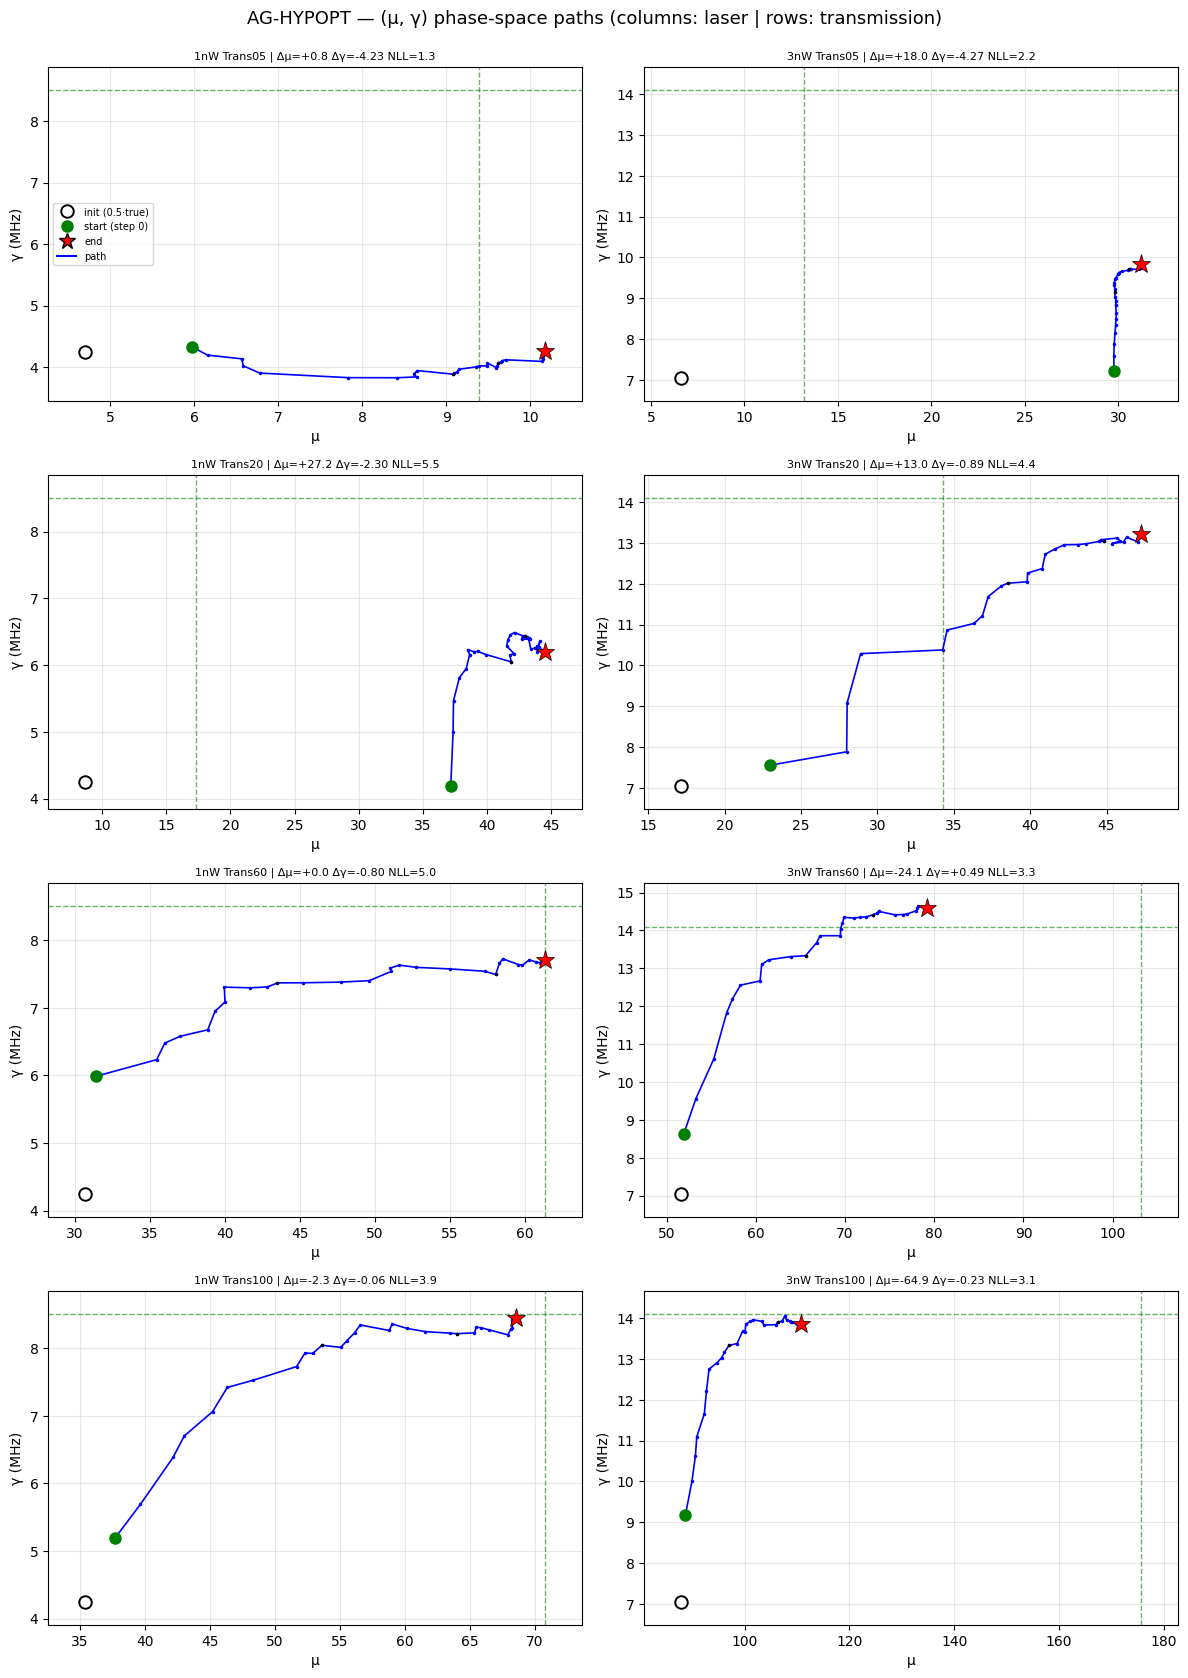

trial finished in 8.0 min
objective = 0.1108 ± 0.0826
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.18    +8.4 |     8.50    4.27   -49.7
1nW Trans20       17.32   44.54  +157.2 |     8.50    6.20   -27.0
1nW Trans60       61.37   61.38    +0.0 |     8.50    7.70    -9.4
1nW Trans100       70.82   68.55    -3.2 |     8.50    8.44    -0.6
3nW Trans05       13.20   31.22  +136.5 |    14.10    9.83   -30.3
3nW Trans20       34.28   47.23   +37.8 |    14.10   13.21    -6.3
3nW Trans60      103.20   79.13   -23.3 |    14.10   14.59    +3.5
3nW Trans100      175.71  110.81   -36.9 |    14.10   13.87    -1.6

weighted objective (T-graded, cap=1.0) = 0.1108 | diverged cells: 0
μ: RMSE 27.456 (rel 76.4%, bias -4.031) | γ: RMSE 2.321 (rel 23.1%, bias -1.534)


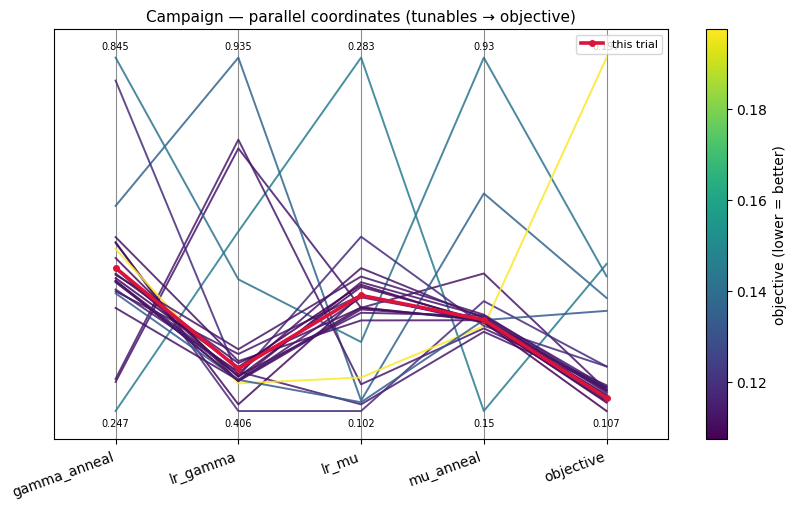

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 24 ran the highest-EI candidate (candidate 5, ei=3.93): `lr_mu=0.1615`, `mu_anneal=0.3513` (effective mu travel 0.133), `lr_gamma=0.4691`, `gamma_anneal=0.4896`. It completed in 8.0 min with objective **0.1108 +/- 0.0826** and **0 diverged cells** — fifth-best. Ranking: trial_21 0.1074 < trial_22 0.1095 < trial_08 0.1099 < trial_15 0.1103 < **trial_24 0.1108** < trial_16 0.1112 < trial_12 0.1115 < ...

Aggregate accuracy: **mu rel-RMSE 76.4%** (RMSE 27.46, bias -4.03); **gamma rel-RMSE 23.1%** (RMSE 2.32, bias -1.53).

Per-cell relative errors:
- **mu:** 1nW T05 +8.4%, T20 +157.2%, **T60 +0.0%**, T100 -3.2% | 3nW T05 +136.5%, T20 +37.8%, T60 -23.3%, T100 -36.9%.
- **gamma:** 1nW T05 -49.7%, T20 -27.0%, T60 -9.4%, T100 -0.6% | 3nW T05 -30.3%, T20 -6.3%, T60 +3.5%, T100 -1.6%.

Another sample in the balanced-gamma, travel ~0.13 region, divergence-free, with a standout 1nW T60 mu (exactly +0.0%) and a strong 1nW T100 (-3.2%). It still landed fifth at 0.1108, just above trial_15, because the mid-T overshoots and 3nW high-T undershoot persist. With this, five runs (08, 15, 22, 24, 21) now sit below 0.111 at travel 0.127-0.138 with balanced gamma, but trial_21's exact point at travel 0.138 remains the single lowest. The optimum is a narrow, high-performing spike rather than a broad basin.

**Summary:** Trial 24 (lr_mu=0.1615, mu_anneal=0.3513, lr_gamma=0.4691, gamma_anneal=0.4896): objective 0.1108 +/- 0.0826 with 0 diverged cells; a near-optimal sample (travel 0.133) with a perfect 1nW T60 (mu +0.0%) landed fifth-best, so trial_21 (0.1074) remains best.
**Key insight:** Balanced gamma at travel ~0.13 keeps producing sub-0.111 results (now five runs), but trial_21's exact point at travel 0.138 is still the lowest — the optimum is a narrow, high-performing spike.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The best five runs cluster at travel 0.127-0.138 with `lr_gamma` ~ `gamma_anneal` ~ 0.47; within that cluster only a handful of small cells (1nW T60/T100, 3nW T20) separate 0.1074 from 0.1112. Remaining gains are marginal at best; the structural residuals are unchanged. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 24 (lr_mu=0.1615, mu_anneal=0.3513, lr_gamma=0.4691, gamma_anneal=0.4896): objective 0.1108 +/- 0.0826 with 0 diverged cells; a near-optimal sample (travel 0.133) with a perfect 1nW T60 (mu +0.0%) landed fifth-best, so trial_21 (0.1074) remains best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Balanced gamma at travel ~0.13 keeps producing sub-0.111 results (now five runs), but trial_21's exact point at travel 0.138 is still the lowest - the optimum is a narrow, high-performing spike"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_24 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_25.ipynb. Open it and follow its cells from the top.
